<a href="https://colab.research.google.com/github/kevinandrespardo2506-boop/inteligencia-artificial-2/blob/main/Copia_de_advanced_ai_kernel_methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# [CELDA 1: Configuración de Entorno e Instalaciones]
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles, make_moons
from sklearn.svm import SVC
from sklearn.decomposition import KernelPCA, PCA
from sklearn.kernel_ridge import KernelRidge
from sklearn.kernel_approximation import RBFSampler
from sklearn.metrics.pairwise import rbf_kernel

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

### 1. Motivación y Formulación Matemática
Muchas veces los datos no son separables linealmente en el espacio original $\mathcal{X} \subset \mathbb{R}^d$.
La solución es proyectar los datos a un espacio de características de mayor dimensión $\mathcal{H}$ (espacio de Hilbert) mediante un mapeo $\phi: \mathcal{X} \to \mathcal{H}$, donde el problema sí sea linealmente separable.

Sin embargo, computar $\phi(x)$ explícitamente puede ser computacionalmente prohibitivo o de dimensión infinita. Aquí entra el **Teorema de Mercer**:
$$K(x_i, x_j) = \langle \phi(x_i), \phi(x_j) \rangle_{\mathcal{H}}$$
Una función kernel calcula el producto interno directamente en el espacio original sin transformar explícitamente los vectores.

* **Kernel RBF (Gaussiano):** $K(x, x') = \exp(-\gamma ||x - x'||^2)$
* **Kernel Polinomial:** $K(x, x') = (x^T x' + c)^d$

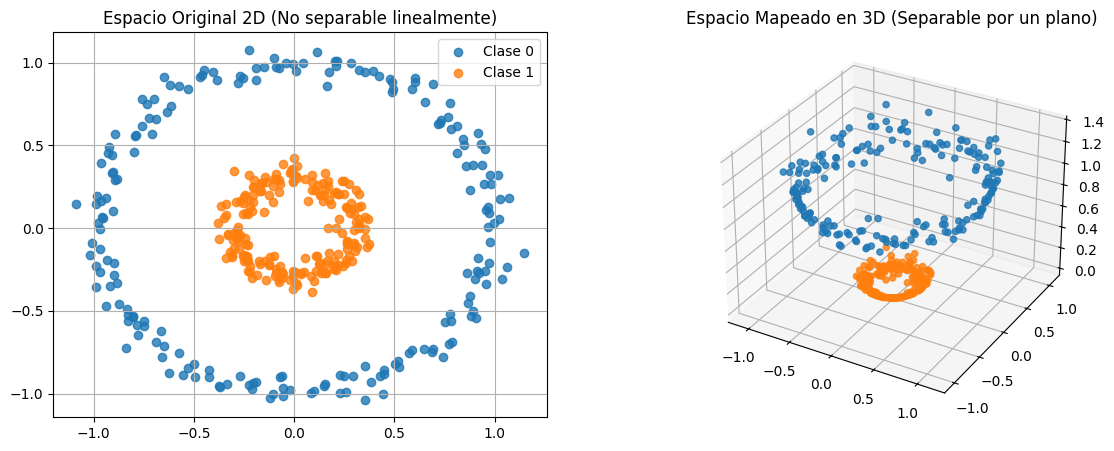

In [ ]:
# [CELDA 2: Visualización del Kernel Trick]
X, y = make_circles(n_samples=400, factor=0.3, noise=0.05, random_state=42)

# Mapeo explícito a 3D: z = x^2 + y^2
z = (X[:, 0]**2 + X[:, 1]**2)

fig = plt.figure(figsize=(14, 5))

# Espacio 2D original
ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(X[y == 0, 0], X[y == 0, 1], label="Clase 0", alpha=0.8)
ax1.scatter(X[y == 1, 0], X[y == 1, 1], label="Clase 1", alpha=0.8)
ax1.set_title("Espacio Original 2D (No separable linealmente)")
ax1.legend()

# Espacio 3D mapeado
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(X[y == 0, 0], X[y == 0, 1], z[y == 0], label="Clase 0", alpha=0.8)
ax2.scatter(X[y == 1, 0], X[y == 1, 1], z[y == 1], label="Clase 1", alpha=0.8)
ax2.set_title("Espacio Mapeado en 3D (Separable por un plano)")
plt.show()

2. Clasificación con Support Vector Machines (SVM) y Kernel RBFMarkdown para Colab:2. Clasificación de Márgenes con KernelsEn SVM, el problema dual depende únicamente de la matriz de Gram $K_{ij} = K(x_i, x_j)$:$$\max_{\alpha} \sum_{i=1}^n \alpha_i - \frac{1}{2}\sum_{i=1}^n \sum_{j=1}^n \alpha_i \alpha_j y_i y_j K(x_i, x_j)$$sujeto a $0 \le \alpha_i \le C$ y $\sum \alpha_i y_i = 0$.

In [ ]:
# [CELDA 3: Frontera de Decisión con SVM no lineal]
clf = SVC(kernel='rbf', C=1.0, gamma='scale')
clf.fit(X, y)

# Malla para graficar la frontera
xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 300), np.linspace(-1.5, 1.5, 300))
Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, Z, levels=15, cmap='RdBu', alpha=0.3)
plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='black') # Frontera
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolors='k')
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=120, facecolors='none', edgecolors='green', label='Vectores de Soporte')
plt.title("SVM con Kernel RBF y Vectores de Soporte Activos")
plt.legend()
plt.show()

3. Reducción de Dimensionalidad No Lineal: Kernel PCA
Markdown para Colab:

3. Kernel Principal Component Analysis (KPCA)
El PCA clásico asume relaciones lineales ortogonales. KPCA aplica el truco del kernel para proyectar los datos a un espacio donde la estructura no lineal se vuelve plana, permitiendo desenrollar variedades no lineales (manifolds como lunas concéntricas o swiss rolls).

In [ ]:
# [CELDA 4: Comparación PCA Lineal vs. Kernel PCA]
X_moons, y_moons = make_moons(n_samples=500, noise=0.08, random_state=42)

linear_pca = PCA(n_components=2)
kpca = KernelPCA(n_components=2, kernel="rbf", gamma=15)

X_pca = linear_pca.fit_transform(X_moons)
X_kpca = kpca.fit_transform(X_moons)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='viridis', edgecolors='k')
axes[0].set_title("Datos Originales (Two Moons)")

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_moons, cmap='viridis', edgecolors='k')
axes[1].set_title("PCA Estándar (No logra separar)")

axes[2].scatter(X_kpca[:, 0], X_kpca[:, 1], c=y_moons, cmap='viridis', edgecolors='k')
axes[2].set_title("Kernel PCA (RBF) - Clústeres linealmente separables")
plt.show()

4. Regresión No Lineal: Kernel Ridge Regression (KRR)Markdown para Colab:4. Kernel Ridge Regression vs. Redes NeuronalesKRR combina regresión Ridge ($L_2$ regularizada) con el truco del kernel. La solución analítica en forma cerrada es:$$\alpha = (K + \lambda I)^{-1} y$$Es ampliamente utilizado como línea base frente a redes neuronales (y base teórica para el análisis del Neural Tangent Kernel o NTK en Deep Learning).

In [ ]:
# [CELDA 5: Kernel Ridge Regression]
rng = np.random.RandomState(42)
X_train = 5 * rng.rand(100, 1)
y_train = np.sin(X_train).ravel() + rng.normal(0, 0.1, X_train.shape[0])

X_test = np.linspace(0, 5, 200)[:, None]

krr = KernelRidge(alpha=0.1, kernel='rbf', gamma=1.0)
krr.fit(X_train, y_train)
y_pred = krr.predict(X_test)

plt.figure(figsize=(9, 5))
plt.scatter(X_train, y_train, color='darkorange', label='Muestras con ruido')
plt.plot(X_test, y_pred, color='navy', lw=2, label='Predicción KRR (RBF)')
plt.plot(X_test, np.sin(X_test), color='gray', linestyle='--', label='Función Real $\sin(x)$')
plt.title("Ajuste de Señal No Lineal con Kernel Ridge Regression")
plt.legend()
plt.show()

5. Tema Avanzado: Escalabilidad mediante Random Fourier Features (RFF)Markdown para Colab:5. ¿Por qué decayeron los Kernels y cómo revivieron? (Escalabilidad y RFF)Problema: Los métodos de kernel tradicionales requieren calcular e invertir la matriz de Gram de tamaño $N \times N$, lo que toma tiempo $\mathcal{O}(N^3)$ y memoria $\mathcal{O}(N^2)$, inviable para millones de datos.Solución (Teorema de Bochner / Rahimi & Recht, 2007): Cualquier kernel continuo de traslación invariable se puede aproximar mediante un mapeo aleatorio de Fourier de baja dimensión:$$z(x) = \sqrt{\frac{2}{D}} \cos(W x + b)$$Esto convierte un problema de kernel no lineal en un modelo lineal rápido de complejidad $\mathcal{O}(N \cdot D)$.

In [ ]:
# [CELDA 6: Aproximación RBF con Random Fourier Features]
rbf_feature_map = RBFSampler(gamma=1.0, n_components=100, random_state=42)
X_rff = rbf_feature_map.fit_transform(X_moons)

print(f"Dimensión original: {X_moons.shape[1]}")
print(f"Dimensión aproximada por RFF: {X_rff.shape[1]}")
print(f"Ahora se puede entrenar un modelo lineal (SGD/LinearSVC) en tiempo O(N)!")